# Evaluate Model v2

Evaluate RT-DETR v2 models on the real test set.

**Model sources:**

- **W&B artifacts**: Load specific checkpoints (e.g. best mAP from a training round)
- **HF Hub**: Load published models from repo branches

**Metrics:**

1. mAP (COCO mAP@50:95, mAP@50, mAP@75)
2. Center-distance P/R/F1 at various distance thresholds
3. Confidence threshold sweep (P/R/F1 vs score threshold)
4. Visual prediction browsing

## Configuration

In [1]:
%load_ext autoreload
%autoreload 2

import torch
from dotenv import load_dotenv

load_dotenv()

HF_DATASET = "kaya-go/moku-v2"
THRESHOLD = 0.05

device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: mps


## Load Datasets


In [2]:
from datasets import load_dataset

from moku.dataset import CATEGORIES, ID_TO_CATEGORY
from moku.evaluation import (
    evaluate_center_distance,
    evaluate_map,
    format_map_per_class,
    format_map_results,
    sweep_confidence_threshold,
)
from moku.runs import list_wandb_model_artifacts, load_model_from_wandb
from moku.model import collate_fn, make_eval_transform
from moku.viz import plot_center_distance_comparison, plot_map_comparison, plot_threshold_sweep

In [3]:
ds_real = load_dataset(HF_DATASET, "real")
print(ds_real)

DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'width', 'height', 'source_dataset', 'objects'],
        num_rows: 382
    })
    validation: Dataset({
        features: ['image', 'image_id', 'width', 'height', 'source_dataset', 'objects'],
        num_rows: 53
    })
    test: Dataset({
        features: ['image', 'image_id', 'width', 'height', 'source_dataset', 'objects'],
        num_rows: 50
    })
})


## Load Models from W&B

List available model artifacts and select which ones to evaluate.

In [4]:
# List available model artifacts from W&B
artifacts_df = list_wandb_model_artifacts()
if not artifacts_df.empty:
    cols = [c for c in ["name", "version", "aliases", "run", "eval_map", "eval_map_50", "epoch", "size_mb"] if c in artifacts_df.columns]
    display(artifacts_df[cols].sort_values("eval_map", ascending=False).reset_index(drop=True))
else:
    print("No model artifacts found in W&B.")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


,name,version,aliases,run,eval_map,eval_map_50,epoch,size_mb
0,model-r5_lr4e-4_linear500:v51,v51,[latest],r5_lr4e-4_linear500,0.607520,0.923377,413.0,80.5
1,model-r5_lr3e-4_cos500:v56,v56,[latest],r5_lr3e-4_cos500,0.584135,0.891032,318.0,80.5
2,model-r5_lr2e-4_cos500:v51,v51,[latest],r5_lr2e-4_cos500,0.557738,0.826632,354.0,80.5
3,model-r5_lr4e-4_cos500:v39,v39,[latest],r5_lr4e-4_cos500,0.533515,0.871535,301.0,80.5
4,model-r5_lr5e-4_cos500:v40,v40,[latest],r5_lr5e-4_cos500,0.532266,0.814004,328.0,80.5
5,model-r5_lr5e-4_linear500:v35,v35,[latest],r5_lr5e-4_linear500,0.516121,0.793500,308.0,80.5


Select artifacts to evaluate. Set the `ARTIFACTS` dict below (label → artifact name).

In [5]:
artifacts_df["name"].tolist()

['model-r5_lr5e-4_linear500:v35',
 'model-r5_lr4e-4_linear500:v51',
 'model-r5_lr5e-4_cos500:v40',
 'model-r5_lr4e-4_cos500:v39',
 'model-r5_lr3e-4_cos500:v56',
 'model-r5_lr2e-4_cos500:v51']

In [7]:
# Set which artifacts to evaluate (base names, :latest is appended automatically)
ARTIFACTS = [
    "model-r5_lr5e-4_linear500",
    "model-r5_lr4e-4_linear500",
    "model-r5_lr5e-4_cos500",
    "model-r5_lr4e-4_cos500",
    "model-r5_lr3e-4_cos500",
    "model-r5_lr2e-4_cos500",
]

# Load models
models = {}
for name in ARTIFACTS:
    artifact_name = f"{name}:latest"
    print(f"Loading {artifact_name}...")
    ip, model = load_model_from_wandb(artifact_name)
    models[name] = {"ip": ip, "model": model}

print(f"\nLoaded {len(models)} models: {list(models.keys())}")

Loading model-r5_lr5e-4_linear500:latest...


wandb: Downloading large artifact 'model-r5_lr5e-4_linear500:latest', 76.78MB. 3 files...
wandb:   3 of 3 files downloaded.  
Done. 00:00:04.0 (19.1MB/s)


Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

Loading model-r5_lr4e-4_linear500:latest...


wandb: Downloading large artifact 'model-r5_lr4e-4_linear500:latest', 76.78MB. 3 files...
wandb:   3 of 3 files downloaded.  
Done. 00:00:21.3 (3.6MB/s)


...

Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

Loading model-r5_lr2e-4_cos500:latest...


wandb: Downloading large artifact 'model-r5_lr2e-4_cos500:latest', 76.78MB. 3 files...
wandb:   3 of 3 files downloaded.  
Done. 00:00:03.7 (20.7MB/s)


Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]


Loaded 6 models: ['model-r5_lr5e-4_linear500', 'model-r5_lr4e-4_linear500', 'model-r5_lr5e-4_cos500', 'model-r5_lr4e-4_cos500', 'model-r5_lr3e-4_cos500', 'model-r5_lr2e-4_cos500']


## mAP on Real Test

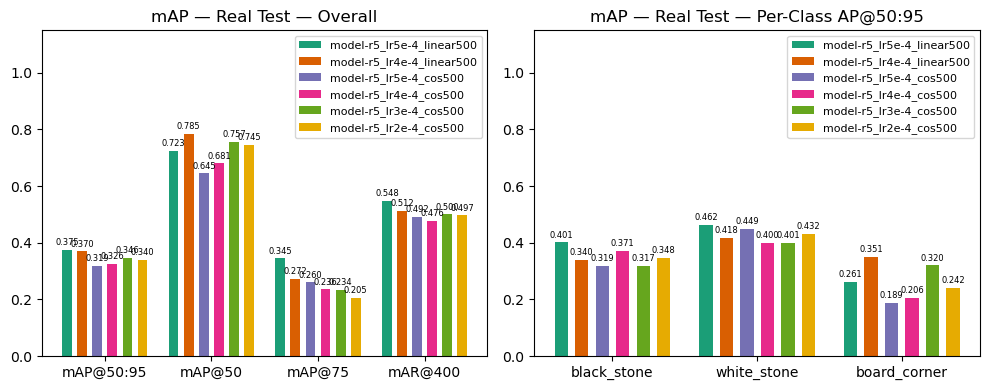

In [8]:
metrics_map = {}

for label, entry in models.items():
    ds_real.set_transform(make_eval_transform(entry["ip"]))
    metrics_map[label] = evaluate_map(
        model=entry["model"],
        dataset=ds_real["test"],
        image_processor=entry["ip"],
        batch_size=8,
    )

if metrics_map:
    plot_map_comparison(metrics_map, title="mAP — Real Test")
else:
    print("No models loaded — nothing to evaluate.")

## Center-Distance Evaluation

mAP penalizes bbox size mismatches, but for our use case only the **center point** matters:

- **board_corner**: center → homography point
- **stones**: center → snap to nearest grid intersection

The center-distance metric reports Precision/Recall/F1 at various distance thresholds
(as % of image diagonal). A detection is "correct" if its center is within X% of the
diagonal from the nearest GT center of the same class.

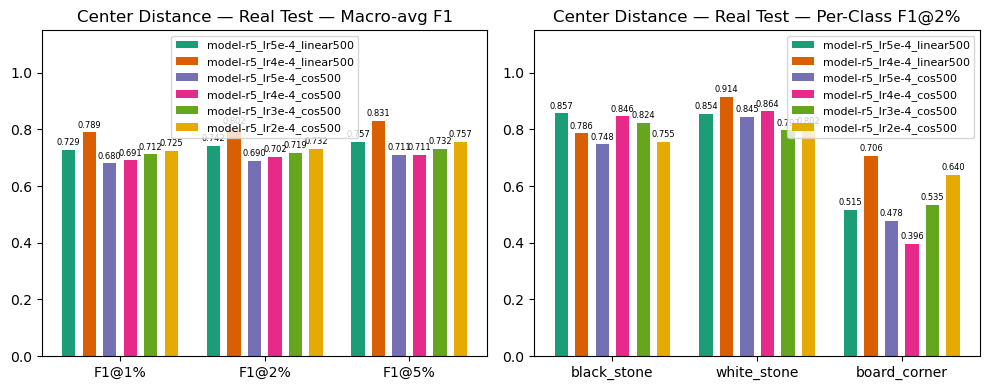

In [9]:
cd_results = {}

for label, entry in models.items():
    ds_real.set_transform(make_eval_transform(entry["ip"]))
    cd_results[label] = evaluate_center_distance(
        model=entry["model"],
        dataset=ds_real["test"],
        image_processor=entry["ip"],
        batch_size=8,
        threshold=THRESHOLD,
    )

if cd_results:
    plot_center_distance_comparison(cd_results, title="Center Distance — Real Test")
else:
    print("No models loaded — nothing to evaluate.")

## Summary Table

In [12]:
import numpy as np
import pandas as pd

# Combine mAP and center-distance into a summary table
summary_rows = []
for label in models:
    row = {"model": label}
    if label in metrics_map:
        m = metrics_map[label]
        row["mAP"] = m.get("map", float("nan"))
        row["mAP_50"] = m.get("map_50", float("nan"))
        row["mAP_75"] = m.get("map_75", float("nan"))
    if label in cd_results:
        cd = cd_results[label]
        # Macro F1 at 2% threshold
        f1s = [cd["per_class"][c]["thresholds"]["2%"]["f1"] for c in ID_TO_CATEGORY.values()]
        row["cd_F1@2%"] = np.mean(f1s)
    summary_rows.append(row)

if summary_rows:
    summary_df = pd.DataFrame(summary_rows).sort_values("mAP", ascending=False).reset_index(drop=True)
    display(summary_df)
else:
    print("No results to summarize.")

,model,mAP,mAP_50,mAP_75,cd_F1@2%
0,model-r5_lr5e-4_linear500,0.375054,0.723498,0.344919,0.742133
1,model-r5_lr4e-4_linear500,0.369678,0.785377,0.271751,0.802000
2,model-r5_lr3e-4_cos500,0.346084,0.756748,0.234291,0.718767
3,model-r5_lr2e-4_cos500,0.340373,0.745007,0.205432,0.732267
4,model-r5_lr4e-4_cos500,0.325798,0.680629,0.235611,0.702000
5,model-r5_lr5e-4_cos500,0.318814,0.645240,0.260160,0.690333


## Confidence Threshold Sweep

Find the optimal confidence threshold by sweeping P/R/F1 (center-distance @2%) vs score threshold.
Inference runs only once per model — threshold filtering is applied post-hoc.

Sweeping confidence threshold for best model: model-r5_lr4e-4_linear500


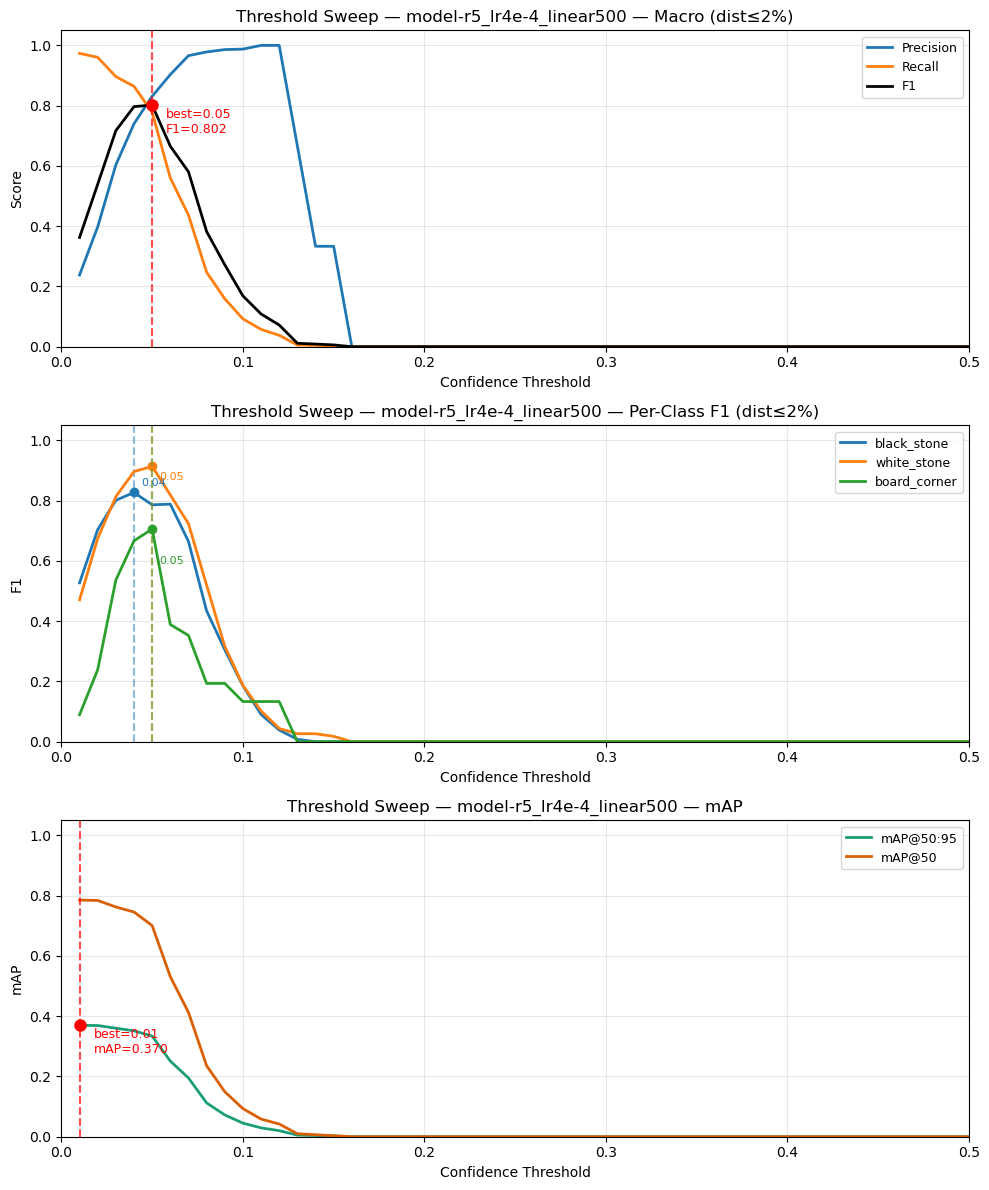

In [19]:
# Pick the best model (highest macro F1@2% center-distance)
if cd_results:
    best_label = max(
        cd_results,
        key=lambda l: np.mean([cd_results[l]["per_class"][c]["thresholds"]["2%"]["f1"] for c in ID_TO_CATEGORY.values()]),
    )
    best_entry = models[best_label]
    print(f"Sweeping confidence threshold for best model: {best_label}")

    ds_real.set_transform(make_eval_transform(best_entry["ip"]))
    sweep = sweep_confidence_threshold(
        model=best_entry["model"],
        dataset=ds_real["test"],
        image_processor=best_entry["ip"],
        batch_size=8,
        distance_threshold=0.02,
    )
    plot_threshold_sweep(sweep, title=f"Threshold Sweep — {best_label}")
else:
    print("No center-distance results — run the previous cell first.")

## Browse Predictions

Interactive widget to browse model predictions on dataset samples.


In [20]:
from moku.viz import browse_predictions

# Build model registry for browsing
all_models = {}
for label, entry in models.items():
    all_models[label] = {"model": entry["model"].to(device), "image_processor": entry["ip"]}

# Build dataset registry
ds_synthetic = load_dataset(HF_DATASET, "synthetic")
all_datasets = {"Real": ds_real, "Synthetic": ds_synthetic}

browse_predictions(all_models, all_datasets, threshold=THRESHOLD)